In [ ]:
import pandas as pd
import numpy as np
import os
print("1. O Python está olhando a partir da pasta:", os.getcwd())
print("2. O que tem dentro dessa pasta:", os.listdir('.'))

# 1. MAPEAMENTO DE CAMINHOS 
# O notebook está em /notebooks, então voltamos um nível (../) para acessar /data
caminho_entrada = '../data/raw/T12 CONTROLE.xlsx'
caminho_saida = '../data/csv/T12_CONTROLE_convertido.csv'
pasta_saida = '../data/csv'

# Garantir que a pasta de destino exista antes de tentar salvar
if not os.path.exists(pasta_saida):
    os.makedirs(pasta_saida)
    print(f"Diretório criado: {pasta_saida}")

# 2. CARREGAMENTO DOS DADOS E DIAGNÓSTICO
print(f"Iniciando a leitura do arquivo: {caminho_entrada}")
print("Aguarde, arquivos .xlsx podem ser lentos para carregar...")

try:
    # Tentativa 1: Forçar o motor padrão de Excel (openpyxl)
    df = pd.read_excel(caminho_entrada, engine='openpyxl')
    print(f"\n✅ Leitura concluída como Excel! O arquivo contém {len(df)} linhas.")

except ValueError as e:
    print(f"\n❌ Erro de Valor retornado pelo pandas: {e}")
    print("\n🔍 Investigando a estrutura real do arquivo...")
    
    # Tentativa 2: Ler os primeiros 150 caracteres do arquivo como se fosse texto bruto
    try:
        with open(caminho_entrada, 'r', encoding='utf-8') as f:
            cabecalho_real = f.read(150)
            print("--- CONTEÚDO BRUTO DO ARQUIVO ---")
            print(cabecalho_real)
            print("---------------------------------")
            print("Diagnóstico: O seu arquivo provavelmente é um arquivo de texto (CSV/TSV) disfarçado de Excel.")
    except UnicodeDecodeError:
        print("Diagnóstico: O arquivo é binário, não é texto. Pode estar corrompido ou requer uma versão antiga do Excel (xls).")

# 3. APLICAÇÃO DO PROTOCOLO DE REQUISITOS (Verificação da Amostragem)
# A coluna 'Timegap (ms)' nos diz o tempo entre as capturas.
# Pelo nosso protocolo, gaps maiores que 100ms são considerados perdas de sinal/piscadas, 
# e não refletem a velocidade do hardware. Vamos isolar o comportamento normal.

# Filtra apenas os gaps menores ou iguais a 100ms
gaps_validos = df[df['Timegap (ms)'] <= 100]['Timegap (ms)']

media_gap_real = gaps_validos.mean()
# Calcula os Hz (1000 milissegundos divididos pelo tempo médio do gap)
taxa_hz_real = 1000 / media_gap_real 

print("\n--- 📊 RELATÓRIO DE QUALIDADE DO EQUIPAMENTO ---")
print("Equipamento: Eye-Tech TM3 (Nominal: 60 Hz)")
print(f"Média do gap de tempo (capturas normais): {media_gap_real:.2f} ms")
print(f"Taxa de amostragem REAL calculada: {taxa_hz_real:.2f} Hz")

# 4. EXPLORAÇÃO INICIAL DE RUÍDO
# Vamos olhar rapidamente para a coluna 'Detection' para entender como o tracker registra perdas.
print("\n--- ⚠️ ANÁLISE DE PERDA DE SINAL ---")
if 'Detection' in df.columns:
    print("Valores encontrados na coluna 'Detection' e suas quantidades:")
    print(df['Detection'].value_counts())
else:
    print("Atenção: Coluna 'Detection' não encontrada neste arquivo.")

# 5. CONVERSÃO E EXPORTAÇÃO
print("\nSalvando arquivo convertido...")
# Salvamos em CSV para acelerar todas as próximas etapas (index=False não cria coluna extra)
df.to_csv(caminho_saida, index=False)
print(f"✅ Conversão concluída com sucesso! Arquivo salvo em: {caminho_saida}")

1. O Python está olhando a partir da pasta: /workspaces/EyeTracking_analysis/notebooks
2. O que tem dentro dessa pasta: ['fase1_conversao.ipynb']
Iniciando a leitura do arquivo: ../data/raw/T12 CONTROLE.xlsx
Aguarde, arquivos .xlsx podem ser lentos para carregar...


BadZipFile: File is not a zip file

In [9]:
caminho_entrada = '../data/raw/T12 CONTROLE.xlsx'

print("🔍 Investigando a verdadeira estrutura do arquivo...\n")

try:
    # Vamos tentar forçar a leitura do arquivo como se ele fosse um arquivo de texto comum
    with open(caminho_entrada, 'r', encoding='utf-8') as f:
        cabecalho = f.read(500) # Lê os primeiros 500 caracteres
        print("✅ DIAGNÓSTICO: O arquivo é texto puro (CSV/TSV disfarçado).")
        print("\n--- INÍCIO DO CONTEÚDO BRUTO ---")
        print(cabecalho)
        print("--------------------------------")
except UnicodeDecodeError:
    print("⚠️ DIAGNÓSTICO: O arquivo é binário. Pode ser um formato muito antigo do Excel (.xls) ou foi corrompido no upload.")
    with open(caminho_entrada, 'rb') as f:
        print(f"Assinatura em bytes: {f.read(30)}")
except Exception as e:
    print(f"Erro inesperado: {e}")

🔍 Investigando a verdadeira estrutura do arquivo...

⚠️ DIAGNÓSTICO: O arquivo é binário. Pode ser um formato muito antigo do Excel (.xls) ou foi corrompido no upload.
Assinatura em bytes: b'\x00\x00\x00\x1cftypisom\x00\x00\x02\x00isomiso2mp41\x00\x00'


In [10]:
# 1. COLOQUE O NOME DO NOVO ARQUIVO AQUI
caminho_entrada = '../data/raw/T43 CONTROLE.xlsx'

print(f"🔍 Investigando a estrutura do arquivo: {caminho_entrada}\n")

try:
    # Tenta ler como texto (CSV/TSV disfarçado)
    with open(caminho_entrada, 'r', encoding='utf-8') as f:
        cabecalho = f.read(500)
        print("✅ SUCESSO: Este arquivo contém dados em formato de texto. Achamos o log!")
        print("\n--- INÍCIO DO CONTEÚDO BRUTO ---")
        print(cabecalho)
        print("--------------------------------")
except UnicodeDecodeError:
    # Se falhar, tenta ler os bytes para ver se é outro vídeo
    print("⚠️ DIAGNÓSTICO: Este arquivo também é binário (provavelmente outro vídeo).")
    with open(caminho_entrada, 'rb') as f:
        print(f"Assinatura em bytes: {f.read(30)}")
except FileNotFoundError:
    print("❌ ERRO: Arquivo não encontrado. Verifique se o nome do arquivo na linha 2 está escrito exatamente igual ao que está na pasta data/raw.")
except Exception as e:
    print(f"Erro inesperado: {e}")

🔍 Investigando a estrutura do arquivo: ../data/raw/T43 CONTROLE.xlsx

⚠️ DIAGNÓSTICO: Este arquivo também é binário (provavelmente outro vídeo).
Assinatura em bytes: b'PK\x03\x04\x14\x00\x08\x08\x08\x00IZ\x97\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x18\x00\x00\x00'


In [ ]:
import pandas as pd
import numpy as np
import os

# 1. MAPEAMENTO DE CAMINHOS
caminho_entrada = '../data/raw/T43 CONTROLE.xlsx'
caminho_saida = '../data/csv/T43_CONTROLE_convertido.csv'
pasta_saida = '../data/csv'

# Garantir que exista a pasta de destino
if not os.path.exists(pasta_saida):
    os.makedirs(pasta_saida)

# 2. CARREGAMENTO DOS DADOS (Agora com o motor correto para arquivos PK/ZIP)
print(f"Iniciando a leitura do arquivo Excel verdadeiro: {caminho_entrada}")
print("Aguarde, extraindo dados do formato .xlsx...")

# Usamos o motor openpyxl, que é o padrão do Python para ler as estruturas ZIP do Excel
df = pd.read_excel(caminho_entrada, engine='openpyxl')
total_linhas = len(df)
print(f"\n✅ Leitura concluída! O arquivo contém {total_linhas} linhas de registro.")

# 3. APLICAÇÃO DO PROTOCOLO DE REQUISITOS (Verificação da Amostragem)
print("\n--- 📊 RELATÓRIO DE QUALIDADE DO EQUIPAMENTO ---")
if 'Timegap (ms)' in df.columns:
    # Filtramos gaps maiores que 100ms (piscadas/perdas) para achar o ritmo normal da máquina
    gaps_validos = df[df['Timegap (ms)'] <= 100]['Timegap (ms)']
    media_gap_real = gaps_validos.mean()
    taxa_hz_real = 1000 / media_gap_real 
    
    print("Equipamento: Eye-Tech TM3 (Nominal: 60 Hz)")
    print(f"Média do gap de tempo (capturas normais): {media_gap_real:.2f} ms")
    print(f"Taxa de amostragem REAL calculada: {taxa_hz_real:.2f} Hz")
else:
    print("Atenção: Coluna 'Timegap (ms)' não encontrada.")

# 4. EXPLORAÇÃO INICIAL DE RUÍDO
print("\n--- ⚠️ ANÁLISE DE PERDA DE SINAL ---")
# Na sua imagem, vi que existem hifens '-' na coluna AOI e valores 0 em coordenadas.
# Vamos mapear se há uma coluna específica de detecção ou contar as falhas de captura.
if 'Duration' in df.columns:
    zeros_duration = (df['Duration'] == 0).sum()
    print(f"Linhas com Duração = 0 (possível ausência de fixação/dado bruto cru): {zeros_duration}")

# 5. CONVERSÃO E EXPORTAÇÃO
print("\nSalvando arquivo convertido...")
df.to_csv(caminho_saida, index=False)
print(f"✅ Conversão concluída com sucesso! Arquivo otimizado salvo em: {caminho_saida}")

Iniciando a leitura do arquivo Excel verdadeiro: ../data/raw/T43 CONTROLE.xlsx
Aguarde, extraindo dados do formato .xlsx...

✅ Leitura concluída! O arquivo contém 11061 linhas de registro.

--- 📊 RELATÓRIO DE QUALIDADE DO EQUIPAMENTO ---
Equipamento: Eye-Tech TM3 (Nominal: 60 Hz)
Média do gap de tempo (capturas normais): 17.21 ms
Taxa de amostragem REAL calculada: 58.09 Hz

--- ⚠️ ANÁLISE DE PERDA DE SINAL ---
Linhas com Duração = 0 (possível ausência de fixação/dado bruto cru): 2

Salvando arquivo convertido...
✅ Conversão concluída com sucesso! Arquivo otimizado salvo em: ../data/csv/T43_CONTROLE_convertido.csv


In [12]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DO ARQUIVO CONVERTIDO DA FASE 1
caminho_csv = '../data/csv/T43_CONTROLE_convertido.csv'
df = pd.read_csv(caminho_csv)

print("--- 🔍 MAPEAMENTO DE RUÍDOS E PISCADAS ---")

# 2. ANÁLISE DE COORDENADAS (Gaze X e Gaze Y)
# Contando valores zero, vazios (NaN) ou strings estranhas
zeros_x = (df['Gaze X'] == 0).sum()
zeros_y = (df['Gaze Y'] == 0).sum()
nulos_x = df['Gaze X'].isna().sum()

print(f"Coordenada Gaze X == 0: {zeros_x} linhas")
print(f"Coordenada Gaze Y == 0: {zeros_y} linhas")
print(f"Coordenadas Vazias (NaN): {nulos_x} linhas")

# 3. ANÁLISE DE PUPILA (Se houver diâmetro 0, o rastreador perdeu o olho)
if 'Pupil Diameter Left (mm)' in df.columns:
    zeros_pupila = (df['Pupil Diameter Left (mm)'] == 0).sum()
    nulos_pupila = df['Pupil Diameter Left (mm)'].isna().sum()
    print(f"\nDiâmetro Pupilar Esquerdo == 0: {zeros_pupila} linhas")
    print(f"Diâmetro Pupilar Vazio (NaN): {nulos_pupila} linhas")
else:
    print("\nAviso: Coluna 'Pupil Diameter Left (mm)' não encontrada com este nome exato.")

# 4. BUSCA POR CARACTERES ESPECIAIS (Hifens)
# Como vi hifens na sua captura de tela, vamos checar se eles poluem os dados
tem_hifen = df.apply(lambda col: col.astype(str).str.contains('-').any()).sum()
print(f"\nExistem {tem_hifen} colunas que contêm o caractere '-' (hífen).")

--- 🔍 MAPEAMENTO DE RUÍDOS E PISCADAS ---
Coordenada Gaze X == 0: 0 linhas
Coordenada Gaze Y == 0: 0 linhas
Coordenadas Vazias (NaN): 0 linhas

Diâmetro Pupilar Esquerdo == 0: 103 linhas
Diâmetro Pupilar Vazio (NaN): 0 linhas

Existem 4 colunas que contêm o caractere '-' (hífen).


In [13]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DOS DADOS
caminho_csv = '../data/csv/T43_CONTROLE_convertido.csv'
caminho_saida = '../data/csv/T43_CONTROLE_limpo.csv'

print("Iniciando a Fase 2: Limpeza e Interpolação Fisiológica...")
df = pd.read_csv(caminho_csv)

# 2. SANITIZAÇÃO DE CARACTERES (Regra 1)
# O Pandas pode ter lido colunas com hífen '-' como texto. Vamos forçar a conversão 
# para NaN (Not a Number) para podermos fazer matemática com elas.
df.replace('-', np.nan, inplace=True)

# 3. INVALIDAÇÃO DE DADOS FALSOS (Regra 2)
col_pupila = 'Pupil Diameter Left (mm)'
# Garante que a coluna de pupila é lida como número
df[col_pupila] = pd.to_numeric(df[col_pupila], errors='coerce')

# Conta quantas linhas têm o olho perdido antes da limpeza
perdas_iniciais = (df[col_pupila] == 0).sum() + df[col_pupila].isna().sum()

# Onde a pupila for 0 ou NaN, transformamos X e Y em NaN (destruindo o dado falso)
mascara_perda = (df[col_pupila] == 0) | (df[col_pupila].isna())
df.loc[mascara_perda, ['Gaze X', 'Gaze Y']] = np.nan

# 4. INTERPOLAÇÃO LINEAR (Regras 3 e 4)
# Limite de 24 frames corresponde a ~413 ms na sua taxa real de 58 Hz.
# Qualquer buraco menor que 24 linhas será preenchido com uma reta ligando os pontos.
df['Gaze X'] = pd.to_numeric(df['Gaze X'], errors='coerce')
df['Gaze Y'] = pd.to_numeric(df['Gaze Y'], errors='coerce')

df['Gaze X'] = df['Gaze X'].interpolate(method='linear', limit=24, limit_direction='forward')
df['Gaze Y'] = df['Gaze Y'].interpolate(method='linear', limit=24, limit_direction='forward')

# 5. AUDITORIA DOS RESULTADOS
# Vamos verificar o que sobrou após o algoritmo tentar "costurar" as piscadas.
perdas_finais = df['Gaze X'].isna().sum()
linhas_recuperadas = perdas_iniciais - perdas_finais

print("\n--- 🛠️ RELATÓRIO DE LIMPEZA METODOLÓGICA ---")
print(f"Total de falhas detectadas (Pupila = 0): {perdas_iniciais} frames.")
print(f"Frames recuperados por interpolação de piscadas (<= 400ms): {linhas_recuperadas} frames.")
print(f"Perdas definitivas (buracos longos, track loss > 400ms): {perdas_finais} frames.")

# 6. SALVAMENTO
df.to_csv(caminho_saida, index=False)
print(f"\n✅ Arquivo limpo e estruturado salvo em: {caminho_saida}")

Iniciando a Fase 2: Limpeza e Interpolação Fisiológica...

--- 🛠️ RELATÓRIO DE LIMPEZA METODOLÓGICA ---
Total de falhas detectadas (Pupila = 0): 103 frames.
Frames recuperados por interpolação de piscadas (<= 400ms): 103 frames.
Perdas definitivas (buracos longos, track loss > 400ms): 0 frames.

✅ Arquivo limpo e estruturado salvo em: ../data/csv/T43_CONTROLE_limpo.csv


In [1]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DOS DADOS LIMPOS DA FASE 2
caminho_entrada = '../data/csv/T43_CONTROLE_limpo.csv'
caminho_saida = '../data/csv/T43_CONTROLE_features.csv'

print("Iniciando a Fase 3: Algoritmo de Classificação I-VT (Velocity Threshold)...")
df = pd.read_csv(caminho_entrada)

# 2. CÁLCULO DE DISTÂNCIA E VELOCIDADE (A Física do Olho)
# Usamos o Teorema de Pitágoras para calcular a distância percorrida em pixels 
# entre a linha atual e a linha anterior.
df['Delta_X'] = df['Gaze X'].diff()
df['Delta_Y'] = df['Gaze Y'].diff()
df['Distancia_px'] = np.sqrt(df['Delta_X']**2 + df['Delta_Y']**2)

# Calculamos a velocidade (Pixels por Segundo)
# Usamos a coluna 'Timegap (ms)' para saber o tempo exato entre as capturas
df['Velocidade_px_s'] = (df['Distancia_px'] / df['Timegap (ms)']) * 1000

# 3. APLICAÇÃO DO LIMIAR DE VELOCIDADE (O Filtro Cognitivo)
# A literatura geralmente define sacadas como movimentos mais rápidos que ~300 graus/segundo.
# Em pixels (variando pela resolução da tela e distância do sujeito), um limiar seguro 
# para iniciar a separação é de 250 a 300 pixels por segundo.
LIMIAR_VELOCIDADE = 250

# Criamos uma nova coluna chamada 'Evento_Cognitivo' e preenchemos tudo como 'Indefinido'
df['Evento_Cognitivo'] = 'Indefinido'

# Regra A: Se a velocidade for MENOR que o limiar -> Fixação
df.loc[df['Velocidade_px_s'] <= LIMIAR_VELOCIDADE, 'Evento_Cognitivo'] = 'Fixação'

# Regra B: Se a velocidade for MAIOR que o limiar -> Sacada
df.loc[df['Velocidade_px_s'] > LIMIAR_VELOCIDADE, 'Evento_Cognitivo'] = 'Sacada'

# Regra C: Se o Gaze X for nulo (lembra das perdas > 400ms?), o evento é 'Perda de Sinal'
df.loc[df['Gaze X'].isna(), 'Evento_Cognitivo'] = 'Perda de Sinal'

# 4. AUDITORIA E RELATÓRIO
total_linhas = len(df)
contagem_eventos = df['Evento_Cognitivo'].value_counts()

print("\n--- 🧠 RELATÓRIO DE ASSINATURAS COGNITIVAS ---")
print(f"Total de registros analisados: {total_linhas}")
print("\nDistribuição dos eventos:")
for evento, quantidade in contagem_eventos.items():
    porcentagem = (quantidade / total_linhas) * 100
    print(f"- {evento}: {quantidade} frames ({porcentagem:.1f}%)")

# 5. SALVAMENTO DA MATRIZ DE FEATURES
df.to_csv(caminho_saida, index=False)
print(f"\n✅ Matriz de features salva em: {caminho_saida}")

Iniciando a Fase 3: Algoritmo de Classificação I-VT (Velocity Threshold)...

--- 🧠 RELATÓRIO DE ASSINATURAS COGNITIVAS ---
Total de registros analisados: 11061

Distribuição dos eventos:
- Sacada: 10027 frames (90.7%)
- Fixação: 1033 frames (9.3%)
- Indefinido: 1 frames (0.0%)

✅ Matriz de features salva em: ../data/csv/T43_CONTROLE_features.csv


In [2]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DOS DADOS LIMPOS
caminho_entrada = '../data/csv/T43_CONTROLE_limpo.csv'
caminho_saida_base = '../data/csv/T43_CONTROLE_features' # Não colocamos .csv ainda, pois salvaremos com o limiar escolhido

print("Iniciando a Fase 3 v2.0: Suavização e Teste de Limiares I-VT...\n")
df = pd.read_csv(caminho_entrada)

# 2. FILTRO DE SUAVIZAÇÃO (SMOOTHING) PARA REDUZIR JITTER
# Usamos uma janela de 3 frames (~50ms) centralizada para não atrasar o sinal.
# min_periods=1 garante que as bordas ou vizinhos de NaN não sejam perdidos.
df['Gaze X_Smooth'] = df['Gaze X'].rolling(window=3, center=True, min_periods=1).mean()
df['Gaze Y_Smooth'] = df['Gaze Y'].rolling(window=3, center=True, min_periods=1).mean()

# 3. CÁLCULO DE FÍSICA CORRIGIDO (Usando os dados suavizados)
df['Delta_X'] = df['Gaze X_Smooth'].diff()
df['Delta_Y'] = df['Gaze Y_Smooth'].diff()
df['Distancia_px'] = np.sqrt(df['Delta_X']**2 + df['Delta_Y']**2)

# Evita divisão por zero caso o Timegap seja 0 em algum frame anômalo
df['Timegap (ms)'] = df['Timegap (ms)'].replace(0, np.nan)
df['Velocidade_px_s'] = (df['Distancia_px'] / df['Timegap (ms)']) * 1000

# 4. CALIBRADOR DE LIMIARES (Threshold Sweep)
limiares_para_testar = [250, 500, 750, 1000]
total_linhas = len(df)

print("--- 🧠 TESTE COMPARATIVO DE LIMIARES DE VELOCIDADE ---")
print("Objetivo Fisiológico: Encontrar o limiar que resulte entre 70% e 90% de Fixações.\n")

for limiar in limiares_para_testar:
    # Cria uma coluna temporária para este teste
    col_teste = f'Evento_{limiar}'
    df[col_teste] = 'Indefinido'
    
    # Aplica as regras
    df.loc[df['Velocidade_px_s'] <= limiar, col_teste] = 'Fixação'
    df.loc[df['Velocidade_px_s'] > limiar, col_teste] = 'Sacada'
    df.loc[df['Gaze X'].isna(), col_teste] = 'Perda de Sinal'
    
    # Calcula as porcentagens
    fixacoes = (df[col_teste] == 'Fixação').sum()
    sacadas = (df[col_teste] == 'Sacada').sum()
    pct_fix = (fixacoes / total_linhas) * 100
    pct_sac = (sacadas / total_linhas) * 100
    
    print(f"Limiar de {limiar} px/s  ->  Fixações: {pct_fix:.1f}%  |  Sacadas: {pct_sac:.1f}%")

print("\n-----------------------------------------------------------")
print("AGUARDANDO DECISÃO DO PESQUISADOR:")
print("Analise as porcentagens acima. Qual dos limiares chegou mais perto da métrica esperada (70-90% de fixação)?")

Iniciando a Fase 3 v2.0: Suavização e Teste de Limiares I-VT...

--- 🧠 TESTE COMPARATIVO DE LIMIARES DE VELOCIDADE ---
Objetivo Fisiológico: Encontrar o limiar que resulte entre 70% e 90% de Fixações.

Limiar de 250 px/s  ->  Fixações: 41.9%  |  Sacadas: 58.1%
Limiar de 500 px/s  ->  Fixações: 70.9%  |  Sacadas: 29.1%
Limiar de 750 px/s  ->  Fixações: 79.3%  |  Sacadas: 20.6%
Limiar de 1000 px/s  ->  Fixações: 83.3%  |  Sacadas: 16.7%

-----------------------------------------------------------
AGUARDANDO DECISÃO DO PESQUISADOR:
Analise as porcentagens acima. Qual dos limiares chegou mais perto da métrica esperada (70-90% de fixação)?


In [3]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO
caminho_entrada = '../data/csv/T43_CONTROLE_limpo.csv'
caminho_saida = '../data/csv/T43_CONTROLE_features.csv'

print("Iniciando a Fase 3: Extração Definitiva de Features (I-VT)...")
df = pd.read_csv(caminho_entrada)

# 2. SUAVIZAÇÃO (Janela de 3 frames)
df['Gaze X_Smooth'] = df['Gaze X'].rolling(window=3, center=True, min_periods=1).mean()
df['Gaze Y_Smooth'] = df['Gaze Y'].rolling(window=3, center=True, min_periods=1).mean()

# 3. FÍSICA E VELOCIDADE
df['Delta_X'] = df['Gaze X_Smooth'].diff()
df['Delta_Y'] = df['Gaze Y_Smooth'].diff()
df['Distancia_px'] = np.sqrt(df['Delta_X']**2 + df['Delta_Y']**2)

df['Timegap (ms)'] = df['Timegap (ms)'].replace(0, np.nan)
df['Velocidade_px_s'] = (df['Distancia_px'] / df['Timegap (ms)']) * 1000

# 4. APLICAÇÃO DO LIMIAR OFICIAL (750 px/s)
LIMIAR_OFICIAL = 750
df['Evento_Cognitivo'] = 'Indefinido'

df.loc[df['Velocidade_px_s'] <= LIMIAR_OFICIAL, 'Evento_Cognitivo'] = 'Fixação'
df.loc[df['Velocidade_px_s'] > LIMIAR_OFICIAL, 'Evento_Cognitivo'] = 'Sacada'
df.loc[df['Gaze X'].isna(), 'Evento_Cognitivo'] = 'Perda de Sinal'

# 5. LIMPEZA DA MATRIZ (Removendo colunas de cálculo intermediário para poupar memória)
colunas_para_remover = ['Gaze X_Smooth', 'Gaze Y_Smooth', 'Delta_X', 'Delta_Y']
df = df.drop(columns=colunas_para_remover)

# 6. EXPORTAÇÃO
df.to_csv(caminho_saida, index=False)
print(f"✅ Matriz final de features salva com sucesso em: {caminho_saida}")
print(f"O arquivo agora contém a coluna 'Evento_Cognitivo' calibrada a {LIMIAR_OFICIAL} px/s.")

Iniciando a Fase 3: Extração Definitiva de Features (I-VT)...
✅ Matriz final de features salva com sucesso em: ../data/csv/T43_CONTROLE_features.csv
O arquivo agora contém a coluna 'Evento_Cognitivo' calibrada a 750 px/s.


In [4]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DOS DADOS (O resultado da Fase 3)
caminho_entrada = '../data/csv/T43_CONTROLE_features.csv'
caminho_ml_vector = '../data/csv/ML_Dataset_Global.csv'

print("Iniciando a Fase 4: Vetorização de Features para Machine Learning...\n")
df = pd.read_csv(caminho_entrada)

# 2. AGRUPAMENTO DE EVENTOS DISCRETOS (A Mágica da Compressão)
# O código abaixo cria um "ID" único para cada bloco contínuo do mesmo evento.
# Ex: Se houver 10 frames de Fixação seguidos, todos recebem o mesmo ID de bloco.
df['Bloco_ID'] = (df['Evento_Cognitivo'] != df['Evento_Cognitivo'].shift()).cumsum()

# Somamos o tempo (Timegap) dentro de cada bloco para descobrir a duração real daquele evento
eventos_df = df.groupby(['Bloco_ID', 'Evento_Cognitivo'])['Timegap (ms)'].sum().reset_index()
eventos_df.rename(columns={'Timegap (ms)': 'Duracao_Evento_ms'}, inplace=True)

# 3. EXTRAÇÃO DAS MÉTRICAS GLOBAIS DO SUJEITO (As Variáveis Independentes - X)
# Filtramos apenas as Fixações
fixacoes = eventos_df[eventos_df['Evento_Cognitivo'] == 'Fixação']
# Filtramos apenas as Sacadas do arquivo original para tirar a velocidade
sacadas_frames = df[df['Evento_Cognitivo'] == 'Sacada']

# Calculamos a estatística descritiva
qtd_fixacoes = len(fixacoes)
media_duracao_fixacao = fixacoes['Duracao_Evento_ms'].mean()
desvio_duracao_fixacao = fixacoes['Duracao_Evento_ms'].std()
velocidade_media_sacada = sacadas_frames['Velocidade_px_s'].mean()

# Razão de tempo (Quanto tempo o sujeito passou processando vs. buscando informação)
tempo_total_fixacao = fixacoes['Duracao_Evento_ms'].sum()
tempo_total_experimento = df['Timegap (ms)'].sum()
taxa_fixacao_total = (tempo_total_fixacao / tempo_total_experimento) * 100

# 4. MONTAGEM DO VETOR (A linha única do paciente)
# Extraímos a classe do nome do arquivo (CONTROLE ou TEA)
id_sujeito = 'T43'
classe_target = 0 # 0 para Controle, 1 para TEA (A Variável Dependente - Y)

vetor_sujeito = {
    'Subject_ID': id_sujeito,
    'Total_Fixacoes': qtd_fixacoes,
    'Media_Duracao_Fixacao_ms': round(media_duracao_fixacao, 2),
    'SD_Duracao_Fixacao_ms': round(desvio_duracao_fixacao, 2),
    'Velocidade_Media_Sacada_px_s': round(velocidade_media_sacada, 2),
    'Taxa_Tempo_Fixacao_%': round(taxa_fixacao_total, 2),
    'Target_Class': classe_target
}

# Transformamos o dicionário em um DataFrame de 1 linha
df_ml = pd.DataFrame([vetor_sujeito])

print("--- 🧠 VETOR DE CARACTERÍSTICAS (FEATURE VECTOR) ---")
for chave, valor in vetor_sujeito.items():
    print(f"{chave}: {valor}")

# 5. SALVAMENTO (Append Mode)
# Como este arquivo será a base final, se ele não existir, nós criamos. 
# Se existir, nós adicionamos a linha no final (modo 'a').
import os
if not os.path.exists(caminho_ml_vector):
    df_ml.to_csv(caminho_ml_vector, index=False)
    print(f"\n✅ Base de ML criada! Vetor salvo em: {caminho_ml_vector}")
else:
    df_ml.to_csv(caminho_ml_vector, mode='a', header=False, index=False)
    print(f"\n✅ Vetor adicionado à base de ML existente em: {caminho_ml_vector}")

Iniciando a Fase 4: Vetorização de Features para Machine Learning...

--- 🧠 VETOR DE CARACTERÍSTICAS (FEATURE VECTOR) ---
Subject_ID: T43
Total_Fixacoes: 778
Media_Duracao_Fixacao_ms: 213.42
SD_Duracao_Fixacao_ms: 251.51
Velocidade_Media_Sacada_px_s: 2744.29
Taxa_Tempo_Fixacao_%: 79.94
Target_Class: 0

✅ Base de ML criada! Vetor salvo em: ../data/csv/ML_Dataset_Global.csv


In [1]:
import pandas as pd

# Caminho para o arquivo bruto e real (usando o motor correto para XLSX)
caminho_bruto = '../data/raw/T43 CONTROLE.xlsx'

print("🔍 Iniciando rastreamento de Marcadores de Eventos (Triggers)...")
df = pd.read_excel(caminho_bruto, engine='openpyxl')

# 1. Análise da coluna Name (Geralmente guarda o nome do arquivo de mídia mostrado)
if 'Name' in df.columns:
    estimulos_name = df['Name'].dropna().unique()
    print("\n--- 🖼️ ESTÍMULOS ENCONTRADOS NA COLUNA 'Name' ---")
    for estimulo in estimulos_name:
        print(f"- {estimulo}")
else:
    print("\nAviso: Coluna 'Name' não encontrada.")

# 2. Análise da coluna AOI (Áreas de Interesse predefinidas no software)
if 'AOI' in df.columns:
    estimulos_aoi = df['AOI'].dropna().unique()
    print("\n--- 🎯 MARCADORES ENCONTRADOS NA COLUNA 'AOI' ---")
    for aoi in estimulos_aoi:
        print(f"- {aoi}")
else:
    print("\nAviso: Coluna 'AOI' não encontrada.")

# 3. Análise de Duração Total para conferência
tempo_total_minutos = (df['Timegap (ms)'].sum()) / 1000 / 60
print(f"\n⏳ Tempo total de gravação deste arquivo: {tempo_total_minutos:.2f} minutos.")

🔍 Iniciando rastreamento de Marcadores de Eventos (Triggers)...

--- 🖼️ ESTÍMULOS ENCONTRADOS NA COLUNA 'Name' ---
- TESTE 27

--- 🎯 MARCADORES ENCONTRADOS NA COLUNA 'AOI' ---
- -
- 3
- 4
- 2.5
- 2
- 3.6
- 1
- 5
- 5.6
- 2006-05-03 00:00:00
- 2006-05-02 00:00:00
- 2.6
- 6

⏳ Tempo total de gravação deste arquivo: 3.46 minutos.


In [4]:
import pandas as pd

caminho_bruto = '../data/raw/T43 CONTROLE.xlsx'
print("⏳ Iniciando Engenharia Reversa da Linha do Tempo (T43) - Correção de Tipos...\n")

# 1. LEITURA DOS DADOS
df = pd.read_excel(caminho_bruto, engine='openpyxl', usecols=['Timegap (ms)', 'AOI'])

# 2. NORMALIZAÇÃO DE TIPOS (A Correção)
# Preenchemos vazios e forçamos absolutamente todos os registros a se tornarem Texto (str).
df['AOI'] = df['AOI'].fillna('Nenhum').astype(str)

# 3. AGRUPAMENTO DE BLOCOS CONTÍNUOS
df['Bloco_ID'] = (df['AOI'] != df['AOI'].shift()).cumsum()
timeline = df.groupby(['Bloco_ID', 'AOI'])['Timegap (ms)'].sum().reset_index()

# Convertendo milissegundos para segundos
timeline['Duracao_segundos'] = timeline['Timegap (ms)'] / 1000

# 4. IMPRESSÃO DO RELATÓRIO
print("--- ⏱️ CRONOGRAMA DE EVENTOS DO EQUIPAMENTO ---")
print("Tempo (Início - Fim)   | Marcador Registrado  | Duração do Bloco")
print("-" * 65)

tempo_acumulado = 0
for index, row in timeline.iterrows():
    marcador = row['AOI']
    duracao = row['Duracao_segundos']
    
    # Filtro: Ignora variações de sinal menores que 0.2 segundos
    if duracao > 0.2: 
        inicio = tempo_acumulado
        fim = tempo_acumulado + duracao
        print(f"[{inicio:05.1f}s - {fim:05.1f}s]  | {marcador:<20} | {duracao:.2f}s")
        
    tempo_acumulado += duracao

print("-" * 65)
print(f"Tempo total mapeado: {tempo_acumulado:.2f} segundos.")

⏳ Iniciando Engenharia Reversa da Linha do Tempo (T43) - Correção de Tipos...

--- ⏱️ CRONOGRAMA DE EVENTOS DO EQUIPAMENTO ---
Tempo (Início - Fim)   | Marcador Registrado  | Duração do Bloco
-----------------------------------------------------------------
[000.0s - 002.9s]  | -                    | 2.94s
[003.1s - 003.3s]  | 4                    | 0.20s
[004.4s - 004.9s]  | 4                    | 0.50s
[006.1s - 007.3s]  | 2.5                  | 1.12s
[007.8s - 008.3s]  | 4                    | 0.48s
[008.4s - 008.9s]  | 4                    | 0.47s
[009.6s - 009.8s]  | -                    | 0.26s
[010.4s - 010.6s]  | 2.5                  | 0.22s
[011.5s - 011.8s]  | 4                    | 0.22s
[011.8s - 012.0s]  | 4                    | 0.22s
[012.4s - 012.8s]  | 4                    | 0.32s
[013.4s - 014.5s]  | 4                    | 1.07s
[015.1s - 015.3s]  | 2.5                  | 0.22s
[015.6s - 015.8s]  | 2.5                  | 0.22s
[016.0s - 016.3s]  | -                    

In [10]:
!pip install opencv-python
!pip uninstall opencv-python -y
!pip install opencv-python-headless

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 49.4 MB/s  0:00:016m0:00:0100:01


In [13]:
import cv2
import numpy as np

# 1. DEFINIÇÃO DO FICHEIRO
caminho_video = '/workspaces/EyeTracking_analysis/data/videos/VIDEO T30 TEA GRAVE.mp4'
# Quando quiser testar o T30, coloque um '#' na linha acima e retire o '#' da linha abaixo:
# caminho_video = '../data/raw/VIDEO T30 TEA GRAVE.mp4'

print(f"Iniciando Visão Computacional no ficheiro:\n{caminho_video}\n")
cap = cv2.VideoCapture(caminho_video)

if not cap.isOpened():
    print("❌ Erro: Não foi possível abrir o vídeo. Verifique se o nome está exato e na pasta correta.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"✅ Vídeo carregado! FPS: {fps:.2f} | Duração: {(total_frames/fps):.2f} s")

    sucesso, frame_anterior = cap.read()
    frame_anterior = cv2.cvtColor(frame_anterior, cv2.COLOR_BGR2GRAY)
    # Filtro Gaussiano para "cegar" o algoritmo em relação aos pontos do Eye Tracker
    frame_anterior = cv2.GaussianBlur(frame_anterior, (21, 21), 0)

    lista_cortes = []
    # Cooldown reduzido para 0.5s para não perdermos a transição de 1s de intervalo
    cooldown_frames = int(fps * 0.5) 
    contador_cooldown = 0  
    frame_atual_idx = 1
    
    # Limiar ajustado: como o vídeo está desfocado, precisamos de um limiar ligeiramente menor
    limiar_corte = 15  

    while True:
        sucesso, frame = cap.read()
        if not sucesso:
            break

        frame_cinzento = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_cinzento_desfocado = cv2.GaussianBlur(frame_cinzento, (21, 21), 0)

        if contador_cooldown == 0:
            diferenca = cv2.absdiff(frame_cinzento_desfocado, frame_anterior)
            media_dif = np.mean(diferenca)

            if media_dif > limiar_corte:
                tempo_segundos = frame_atual_idx / fps
                lista_cortes.append(tempo_segundos)
                contador_cooldown = cooldown_frames
        else:
            contador_cooldown -= 1 

        frame_anterior = frame_cinzento_desfocado
        frame_atual_idx += 1

    cap.release()

    # 4. AUDITORIA: Calculando a duração entre os cortes
    print("\n--- 🎬 RELATÓRIO DE MUDANÇAS DE ECRÃ (TRIGGERS) ---")
    if len(lista_cortes) > 0:
        print(f"[{0.000:>7.3f}s] Início do vídeo")
        
        for i in range(len(lista_cortes)):
            tempo_atual = lista_cortes[i]
            
            # Calcula quanto tempo passou desde o corte anterior
            if i == 0:
                duracao = tempo_atual
            else:
                duracao = tempo_atual - lista_cortes[i-1]
                
            print(f"[{tempo_atual:>7.3f}s] Mudança {i+1:02d} detetada (Bloco anterior durou: {duracao:.3f}s)")
            
    print(f"\nTotal de mudanças (Faces/Intervalos) detetadas: {len(lista_cortes)}")

Iniciando Visão Computacional no ficheiro:
/workspaces/EyeTracking_analysis/data/videos/VIDEO T30 TEA GRAVE.mp4

✅ Vídeo carregado! FPS: 25.00 | Duração: 186.96 s

--- 🎬 RELATÓRIO DE MUDANÇAS DE ECRÃ (TRIGGERS) ---
[  0.000s] Início do vídeo
[  1.760s] Mudança 01 detetada (Bloco anterior durou: 1.760s)
[  2.760s] Mudança 02 detetada (Bloco anterior durou: 1.000s)
[ 80.640s] Mudança 03 detetada (Bloco anterior durou: 77.880s)
[ 83.480s] Mudança 04 detetada (Bloco anterior durou: 2.840s)
[110.640s] Mudança 05 detetada (Bloco anterior durou: 27.160s)
[113.440s] Mudança 06 detetada (Bloco anterior durou: 2.800s)
[114.360s] Mudança 07 detetada (Bloco anterior durou: 0.920s)
[117.120s] Mudança 08 detetada (Bloco anterior durou: 2.760s)
[136.600s] Mudança 09 detetada (Bloco anterior durou: 19.480s)
[139.360s] Mudança 10 detetada (Bloco anterior durou: 2.760s)
[140.200s] Mudança 11 detetada (Bloco anterior durou: 0.840s)
[142.960s] Mudança 12 detetada (Bloco anterior durou: 2.760s)
[143.840s] 

In [15]:
import cv2
import numpy as np

# 1. DEFINIÇÃO DO FICHEIRO
caminho_video = '/workspaces/EyeTracking_analysis/data/videos/VIDEO FACES T38_ CONTROLE.mp4'

print(f"Iniciando Visão Computacional de ALTA SENSIBILIDADE:\n{caminho_video}\n")
cap = cv2.VideoCapture(caminho_video)

if not cap.isOpened():
    print("❌ Erro: Não foi possível abrir o vídeo. Verifique se o nome está exato e na pasta correta.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    sucesso, frame_anterior = cap.read()
    frame_anterior = cv2.cvtColor(frame_anterior, cv2.COLOR_BGR2GRAY)
    # Desfoque muito mais leve (9x9) apenas para "borrar" o ponto vermelho
    frame_anterior = cv2.GaussianBlur(frame_anterior, (9, 9), 0)

    lista_cortes = []
    # Cooldown de 0.8s. Como o intervalo mais curto é de 1.0s, o algoritmo 
    # volta a ficar alerta 0.2s antes da próxima imagem aparecer.
    cooldown_frames = int(fps * 0.8) 
    contador_cooldown = 0  
    frame_atual_idx = 1
    
    # LIMIAR CIRÚRGICO: Baixamos de 15 para 3. Vai detetar a menor alteração de contraste da face.
    limiar_corte = 3  

    while True:
        sucesso, frame = cap.read()
        if not sucesso:
            break

        frame_cinzento = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_cinzento_desfocado = cv2.GaussianBlur(frame_cinzento, (9, 9), 0)

        if contador_cooldown == 0:
            diferenca = cv2.absdiff(frame_cinzento_desfocado, frame_anterior)
            media_dif = np.mean(diferenca)

            if media_dif > limiar_corte:
                tempo_segundos = frame_atual_idx / fps
                lista_cortes.append(tempo_segundos)
                contador_cooldown = cooldown_frames
        else:
            contador_cooldown -= 1 

        frame_anterior = frame_cinzento_desfocado
        frame_atual_idx += 1

    cap.release()

    # 4. AUDITORIA: Calculando a duração entre os cortes
    print("\n--- 🎬 RELATÓRIO DE MUDANÇAS DE ECRÃ (TRIGGERS) ---")
    if len(lista_cortes) > 0:
        print(f"[{0.000:>7.3f}s] Início do vídeo")
        
        for i in range(len(lista_cortes)):
            tempo_atual = lista_cortes[i]
            duracao = tempo_atual if i == 0 else tempo_atual - lista_cortes[i-1]
            print(f"[{tempo_atual:>7.3f}s] Mudança {i+1:02d} (Bloco anterior durou: {duracao:.3f}s)")
            
    print(f"\nTotal de mudanças detetadas: {len(lista_cortes)}")
    print("Objetivo Clínico: Encontrar ~60 mudanças (30 faces + 30 intervalos).")

Iniciando Visão Computacional de ALTA SENSIBILIDADE:
/workspaces/EyeTracking_analysis/data/videos/VIDEO FACES T38_ CONTROLE.mp4


--- 🎬 RELATÓRIO DE MUDANÇAS DE ECRÃ (TRIGGERS) ---
[  0.000s] Início do vídeo
[  2.040s] Mudança 01 (Bloco anterior durou: 2.040s)
[  3.080s] Mudança 02 (Bloco anterior durou: 1.040s)
[  6.080s] Mudança 03 (Bloco anterior durou: 3.000s)
[  7.080s] Mudança 04 (Bloco anterior durou: 1.000s)
[ 10.000s] Mudança 05 (Bloco anterior durou: 2.920s)
[ 10.960s] Mudança 06 (Bloco anterior durou: 0.960s)
[ 13.880s] Mudança 07 (Bloco anterior durou: 2.920s)
[ 14.880s] Mudança 08 (Bloco anterior durou: 1.000s)
[ 17.920s] Mudança 09 (Bloco anterior durou: 3.040s)
[ 18.880s] Mudança 10 (Bloco anterior durou: 0.960s)
[ 21.760s] Mudança 11 (Bloco anterior durou: 2.880s)
[ 22.760s] Mudança 12 (Bloco anterior durou: 1.000s)
[ 25.760s] Mudança 13 (Bloco anterior durou: 3.000s)
[ 26.720s] Mudança 14 (Bloco anterior durou: 0.960s)
[ 29.600s] Mudança 15 (Bloco anterior durou: 2.880

DESCOBRIR TEMPO E MARCAÇÕES (30/04)

In [3]:
import pandas as pd
from pathlib import Path

# Caminho do arquivo Excel
arquivo_xlsx = Path("/workspaces/EyeTracking_analysis/data/raw/T30 TEA GRAVE.xlsx")

# Pasta de saída
pasta_saida = Path("/workspaces/EyeTracking_analysis/data/csv")
pasta_saida.mkdir(parents=True, exist_ok=True)

# Nome do arquivo CSV
arquivo_csv = pasta_saida / (arquivo_xlsx.stem + ".csv")

# Ler Excel
df = pd.read_excel(arquivo_xlsx)

# Salvar como CSV
df.to_csv(arquivo_csv, index=False)

print(f"Arquivo salvo em: {arquivo_csv}")

Arquivo salvo em: /workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv


In [8]:
import pandas as pd
import numpy as np
import os

print("\n" + "="*60)
print("INICIANDO SINCRONIZAÇÃO RELATIVA E EXTRAÇÃO DE FEATURES")
print("="*60)

# 1. CAMINHOS CORRIGIDOS (Não inverta as chaves!)
ARQUIVO_TEMPOS = '/workspaces/EyeTracking_analysis/reports/tabela_tempos_estimulos_faces_limpa.csv'

DADOS_EYE_TRACKER = {
    'T43_CONTROLE': '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv', 
    'T30_TEA': '/workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv'
}

df_tempos = pd.read_csv(ARQUIVO_TEMPOS)

def extrair_features(paciente_id, caminho_et, grupo):
    print(f"\n--- Processando: {paciente_id} ({grupo}) ---")
    
    if not os.path.exists(caminho_et):
        print(f"❌ Arquivo {caminho_et} não encontrado.")
        return pd.DataFrame()

    df_raw = pd.read_csv(caminho_et)
    
    id_busca = 'control_43' if '43' in paciente_id else 'TEA_G_30'
    tempos_pasc = df_tempos[df_tempos['Paciente_ID'] == id_busca].sort_values('Face_Ordem')

    if tempos_pasc.empty:
        print("❌ Paciente não encontrado na matriz do EEG.")
        return pd.DataFrame()

    # O SEGREDO 1: O Tempo Absoluto da Face 1 no EEG
    onset_primeira_face_eeg = tempos_pasc.iloc[0]['Onset_Segundos']
    
    # O SEGREDO 2: O Marco Zero no Eye Tracker
    # Limpamos a coluna AOI e procuramos o primeiro milissegundo em que uma AOI válida (1 a 6) apareceu
    df_raw['AOI_Num'] = pd.to_numeric(df_raw['AOI'], errors='coerce').fillna(0).astype(int)
    linhas_com_aoi = df_raw[df_raw['AOI_Num'] > 0]
    
    if linhas_com_aoi.empty:
        print("❌ Nenhuma fixação em AOI encontrada neste ficheiro.")
        return pd.DataFrame()
        
    ancora_tempo_et = linhas_com_aoi['Time (ms)'].iloc[0]
    print(f"✔️ Âncora do Eye Tracker localizada em: {ancora_tempo_et} ms")

    features_paciente = []
    
    for _, row in tempos_pasc.iterrows():
        face_idx = row['Face_Ordem']
        emocao = row['Estimulo']
        
        # CÁLCULO RELATIVO: Quanto tempo passou desde a Face 1?
        tempo_decorrido_desde_inicio = row['Onset_Segundos'] - onset_primeira_face_eeg
        
        # APLICANDO A ÂNCORA: Início exato = Âncora ET + Tempo Decorrido
        inicio = ancora_tempo_et + (tempo_decorrido_desde_inicio * 1000)
        fim = inicio + (row['Duracao_Segundos'] * 1000)
        
        fatia = df_raw[(df_raw['Time (ms)'] >= inicio) & (df_raw['Time (ms)'] <= fim)]
        
        if not fatia.empty:
            pupila_l = pd.to_numeric(fatia['Pupil Diameter Left (mm)'], errors='coerce').mean()
            pupila_r = pd.to_numeric(fatia['Pupil Diameter Right (mm)'], errors='coerce').mean()
            pupila_final = np.nanmean([pupila_l, pupila_r])

            ol_olhos = fatia[fatia['AOI_Num'].isin([1, 4])]['Timegap (ms)'].sum()
            ol_nariz = fatia[fatia['AOI_Num'].isin([2, 5])]['Timegap (ms)'].sum()
            ol_boca  = fatia[fatia['AOI_Num'].isin([3, 6])]['Timegap (ms)'].sum()
            
            features_paciente.append({
                'ID': paciente_id,
                'Grupo': grupo,
                'Face_N': face_idx,
                'Emocao': emocao,
                'Pupila_Media_mm': round(pupila_final, 3) if not np.isnan(pupila_final) else 0.0,
                'OL_Olhos_ms': ol_olhos,
                'OL_Nariz_ms': ol_nariz,
                'OL_Boca_ms': ol_boca,
                'Tempo_Total_Face_ms': fatia['Timegap (ms)'].sum()
            })

    return pd.DataFrame(features_paciente)

# 3. EXECUÇÃO 
features_t43 = extrair_features('T43_CONTROLE', DADOS_EYE_TRACKER['T43_CONTROLE'], 'CONTROLE')
features_t30 = extrair_features('T30_TEA', DADOS_EYE_TRACKER['T30_TEA'], 'TEA')

dataset_final = pd.concat([features_t43, features_t30], ignore_index=True)
caminho_dataset_ml = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
dataset_final.to_csv(caminho_dataset_ml, index=False)

print("\n" + "="*60)
print("🎯 DATASET PRONTO PARA MACHINE LEARNING!")
print(f"Total de faces processadas: {len(dataset_final)}")
print(f"Ficheiro salvo em: {caminho_dataset_ml}")
print("="*60)
display(dataset_final.head(10))


INICIANDO SINCRONIZAÇÃO RELATIVA E EXTRAÇÃO DE FEATURES

--- Processando: T43_CONTROLE (CONTROLE) ---
✔️ Âncora do Eye Tracker localizada em: 3077 ms

--- Processando: T30_TEA (TEA) ---
✔️ Âncora do Eye Tracker localizada em: 3011 ms

🎯 DATASET PRONTO PARA MACHINE LEARNING!
Total de faces processadas: 4
Ficheiro salvo em: /workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv


,ID,Grupo,Face_N,Emocao,Pupila_Media_mm,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Total_Face_ms
0,T43_CONTROLE,CONTROLE,1,FF,2.150,0,0,183,183
1,T30_TEA,TEA,1,FF,3.135,17,0,0,17
2,T30_TEA,TEA,12,FR,-0.500,67,0,0,67
3,T30_TEA,TEA,27,FR,1.305,0,0,0,33


START - CORRETO

In [9]:
import pandas as pd
import numpy as np
import os

print("\n" + "="*60)
print("SINCRONIZAÇÃO ABSOLUTA: BASEADA NA VISÃO COMPUTACIONAL")
print("="*60)

# 1. CAMINHOS (Mantidos os seus caminhos corrigidos)
ARQUIVO_TEMPOS = '/workspaces/EyeTracking_analysis/reports/tabela_tempos_estimulos_faces_limpa.csv'

DADOS_EYE_TRACKER = {
    'T43_CONTROLE': '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv', 
    'T30_TEA': '/workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv'
}

df_tempos = pd.read_csv(ARQUIVO_TEMPOS)

def extrair_features(paciente_id, caminho_et, grupo):
    print(f"\n--- Processando: {paciente_id} ({grupo}) ---")
    
    if not os.path.exists(caminho_et):
        print(f"❌ Arquivo {caminho_et} não encontrado.")
        return pd.DataFrame()

    df_raw = pd.read_csv(caminho_et)
    
    id_busca = 'control_43' if '43' in paciente_id else 'TEA_G_30'
    tempos_pasc = df_tempos[df_tempos['Paciente_ID'] == id_busca].sort_values('Face_Ordem')

    if tempos_pasc.empty:
        print("❌ Paciente não encontrado na matriz do EEG.")
        return pd.DataFrame()

    # O SEGREDO 1: O Tempo Absoluto da Face 1 no EEG
    onset_primeira_face_eeg = tempos_pasc.iloc[0]['Onset_Segundos']
    
    # O SEGREDO 2: O Marco Zero baseado na Visão Computacional (2040ms)
    # Pegamos o primeiro tempo gravado pelo equipamento e somamos o atraso de ecrã cinza
    tempo_inicio_arquivo = df_raw['Time (ms)'].min()
    ancora_tempo_et = tempo_inicio_arquivo + 2040 
    
    print(f"✔️ Âncora do vídeo localizada em: {ancora_tempo_et} ms")

    features_paciente = []
    df_raw['AOI_Num'] = pd.to_numeric(df_raw['AOI'], errors='coerce').fillna(0).astype(int)
    
    for _, row in tempos_pasc.iterrows():
        face_idx = row['Face_Ordem']
        emocao = row['Estimulo']
        
        # CÁLCULO RELATIVO
        tempo_decorrido_desde_inicio = row['Onset_Segundos'] - onset_primeira_face_eeg
        
        # APLICANDO A ÂNCORA
        inicio = ancora_tempo_et + (tempo_decorrido_desde_inicio * 1000)
        fim = inicio + (row['Duracao_Segundos'] * 1000)
        
        fatia = df_raw[(df_raw['Time (ms)'] >= inicio) & (df_raw['Time (ms)'] <= fim)]
        
        if fatia.empty:
            print(f"  ⚠️ Face {face_idx:02d} ({emocao}) - Fora do ficheiro (Início: {inicio:.0f}ms)")
            continue
            
        # EXTRAÇÃO DE MÉTRICAS (Features)
        pupila_l = pd.to_numeric(fatia['Pupil Diameter Left (mm)'], errors='coerce').mean()
        pupila_r = pd.to_numeric(fatia['Pupil Diameter Right (mm)'], errors='coerce').mean()
        pupila_final = np.nanmean([pupila_l, pupila_r])

        ol_olhos = fatia[fatia['AOI_Num'].isin([1, 4])]['Timegap (ms)'].sum()
        ol_nariz = fatia[fatia['AOI_Num'].isin([2, 5])]['Timegap (ms)'].sum()
        ol_boca  = fatia[fatia['AOI_Num'].isin([3, 6])]['Timegap (ms)'].sum()
        
        features_paciente.append({
            'ID': paciente_id,
            'Grupo': grupo,
            'Face_N': face_idx,
            'Emocao': emocao,
            'Pupila_Media_mm': round(pupila_final, 3) if not np.isnan(pupila_final) else 0.0,
            'OL_Olhos_ms': ol_olhos,
            'OL_Nariz_ms': ol_nariz,
            'OL_Boca_ms': ol_boca,
            'Tempo_Total_Face_ms': fatia['Timegap (ms)'].sum()
        })

    return pd.DataFrame(features_paciente)

# 3. EXECUÇÃO 
features_t43 = extrair_features('T43_CONTROLE', DADOS_EYE_TRACKER['T43_CONTROLE'], 'CONTROLE')
features_t30 = extrair_features('T30_TEA', DADOS_EYE_TRACKER['T30_TEA'], 'TEA')

dataset_final = pd.concat([features_t43, features_t30], ignore_index=True)
caminho_dataset_ml = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
dataset_final.to_csv(caminho_dataset_ml, index=False)

print("\n" + "="*60)
print("🎯 DATASET PRONTO PARA MACHINE LEARNING!")
print(f"Total de faces processadas: {len(dataset_final)}")
print(f"Ficheiro salvo em: {caminho_dataset_ml}")
print("="*60)
display(dataset_final.head(10))


SINCRONIZAÇÃO ABSOLUTA: BASEADA NA VISÃO COMPUTACIONAL

--- Processando: T43_CONTROLE (CONTROLE) ---
✔️ Âncora do vídeo localizada em: 2040 ms
  ⚠️ Face 01 (FF) - Fora do ficheiro (Início: 2040ms)
  ⚠️ Face 02 (FN) - Fora do ficheiro (Início: 6040ms)
  ⚠️ Face 03 (FR) - Fora do ficheiro (Início: 10040ms)
  ⚠️ Face 05 (FN) - Fora do ficheiro (Início: 18040ms)
  ⚠️ Face 06 (FR) - Fora do ficheiro (Início: 22040ms)
  ⚠️ Face 07 (FF) - Fora do ficheiro (Início: 26040ms)
  ⚠️ Face 08 (FN) - Fora do ficheiro (Início: 30040ms)
  ⚠️ Face 09 (FR) - Fora do ficheiro (Início: 34040ms)
  ⚠️ Face 10 (FF) - Fora do ficheiro (Início: 38040ms)
  ⚠️ Face 11 (FN) - Fora do ficheiro (Início: 42040ms)
  ⚠️ Face 12 (FR) - Fora do ficheiro (Início: 46040ms)
  ⚠️ Face 13 (FF) - Fora do ficheiro (Início: 50040ms)
  ⚠️ Face 14 (FN) - Fora do ficheiro (Início: 54040ms)
  ⚠️ Face 16 (FF) - Fora do ficheiro (Início: 62040ms)
  ⚠️ Face 17 (FN) - Fora do ficheiro (Início: 66040ms)
  ⚠️ Face 18 (FR) - Fora do fiche

,ID,Grupo,Face_N,Emocao,Pupila_Media_mm,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Total_Face_ms
0,T43_CONTROLE,CONTROLE,4,FF,4.560,17,0,0,17
1,T43_CONTROLE,CONTROLE,15,FR,4.950,0,0,17,17
2,T43_CONTROLE,CONTROLE,30,FR,5.270,0,17,0,17
3,T30_TEA,TEA,4,FF,4.045,17,0,0,17


In [10]:
import pandas as pd

print("="*60)
print("RAIO-X DO FICHEIRO EYE TRACKER (T43)")
print("="*60)

caminho_t43 = '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv'
df_raw = pd.read_csv(caminho_t43)

# 1. Anatomia do Tempo
tempo_min = df_raw['Time (ms)'].min()
tempo_max = df_raw['Time (ms)'].max()
total_linhas = len(df_raw)

print(f"Total de registos (linhas): {total_linhas}")
print(f"O ficheiro começa no milissegundo: {tempo_min}")
print(f"O ficheiro termina no milissegundo: {tempo_max} ({(tempo_max/1000)/60:.1f} minutos)")
print("\nPrimeiras 10 linhas para entendermos os saltos de tempo:")
display(df_raw[['No.', 'Time (ms)', 'Timegap (ms)', 'Duration', 'AOI']].head(10))

print("\nE para ver como o tempo se comporta no meio do ficheiro:")
display(df_raw[['No.', 'Time (ms)', 'Timegap (ms)', 'Duration', 'AOI']].iloc[500:510])

RAIO-X DO FICHEIRO EYE TRACKER (T43)
Total de registos (linhas): 11061
O ficheiro começa no milissegundo: 0
O ficheiro termina no milissegundo: 203729 (3.4 minutos)

Primeiras 10 linhas para entendermos os saltos de tempo:


,No.,Time (ms),Timegap (ms),Duration,AOI
0,1,0,0,0,-
1,2,17,17,17,-
2,3,33,17,17,-
3,4,50,17,17,-
4,5,67,17,17,-
5,6,83,17,17,-
6,7,100,17,17,-
7,8,116,17,17,-
8,9,133,17,17,-
9,10,150,17,17,-



E para ver como o tempo se comporta no meio do ficheiro:


,No.,Time (ms),Timegap (ms),Duration,AOI
500,501,10946,17,17,2.5
501,502,10962,17,17,2.5
502,503,10979,17,17,2.5
503,504,10996,17,17,4
504,505,11012,17,17,2.5
505,506,11029,17,17,2.5
506,507,11046,17,17,4
507,508,11062,17,17,4
508,509,11079,17,17,4
509,510,11096,17,17,2.5


In [11]:
import pandas as pd
import numpy as np
import os

print("\n" + "="*60)
print("SINCRONIZAÇÃO ABSOLUTA: JANELA RÍGIDA DE 3 SEGUNDOS")
print("="*60)

# 1. CAMINHOS DE REDE
ARQUIVO_TEMPOS = '/workspaces/EyeTracking_analysis/reports/tabela_tempos_estimulos_faces_limpa.csv'

DADOS_EYE_TRACKER = {
    'T43_CONTROLE': '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv', 
    'T30_TEA': '/workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv'
}

df_tempos = pd.read_csv(ARQUIVO_TEMPOS)

def extrair_features(paciente_id, caminho_et, grupo):
    print(f"\n--- Processando: {paciente_id} ({grupo}) ---")
    
    if not os.path.exists(caminho_et):
        print(f"❌ Arquivo {caminho_et} não encontrado.")
        return pd.DataFrame()

    df_raw = pd.read_csv(caminho_et)
    
    # Padronização do ID para busca na matriz
    id_busca = 'control_43' if '43' in paciente_id else 'TEA_G_30'
    tempos_pasc = df_tempos[df_tempos['Paciente_ID'] == id_busca].sort_values('Face_Ordem')

    # 1. Ponto Zero EEG (Tempo real do primeiro estímulo gravado)
    onset_primeira_face_eeg = tempos_pasc.iloc[0]['Onset_Segundos']
    
    # 2. Ponto Zero Eye Tracker (Início do ficheiro + 2040ms de atraso do ecrã basal)
    tempo_inicio_arquivo = df_raw['Time (ms)'].min()
    ancora_tempo_et = tempo_inicio_arquivo + 2040 
    
    features_paciente = []
    
    # Limpeza preventiva: Garantir que a coluna AOI é estritamente numérica para os cálculos
    df_raw['AOI_Num'] = pd.to_numeric(df_raw['AOI'], errors='coerce').fillna(0).astype(int)
    
    for _, row in tempos_pasc.iterrows():
        face_idx = row['Face_Ordem']
        emocao = row['Estimulo']
        
        # CÁLCULO RELATIVO E CORTE DE 3000ms
        tempo_decorrido = row['Onset_Segundos'] - onset_primeira_face_eeg
        
        inicio = ancora_tempo_et + (tempo_decorrido * 1000)
        fim = inicio + 3000  # A janela matemática exata de 3 segundos
        
        # O Fatiamento (Epoching)
        fatia = df_raw[(df_raw['Time (ms)'] >= inicio) & (df_raw['Time (ms)'] <= fim)]
        
        if fatia.empty:
            print(f"  ⚠️ Face {face_idx:02d} ({emocao}) - Sem dados oculares neste período.")
            continue
            
        # EXTRAÇÃO DAS FEATURES 
        # Carga Cognitiva (Pupilometria)
        pupila_l = pd.to_numeric(fatia['Pupil Diameter Left (mm)'], errors='coerce').mean()
        pupila_r = pd.to_numeric(fatia['Pupil Diameter Right (mm)'], errors='coerce').mean()
        pupila_final = np.nanmean([pupila_l, pupila_r])

        # Atenção Direcionada (Tempo em cada AOI)
        ol_olhos = fatia[fatia['AOI_Num'].isin([1, 4])]['Timegap (ms)'].sum()
        ol_nariz = fatia[fatia['AOI_Num'].isin([2, 5])]['Timegap (ms)'].sum()
        ol_boca  = fatia[fatia['AOI_Num'].isin([3, 6])]['Timegap (ms)'].sum()
        
        features_paciente.append({
            'ID': paciente_id,
            'Grupo': grupo,
            'Face_N': face_idx,
            'Emocao': emocao,
            'Pupila_Media_mm': round(pupila_final, 3) if not np.isnan(pupila_final) else 0.0,
            'OL_Olhos_ms': ol_olhos,
            'OL_Nariz_ms': ol_nariz,
            'OL_Boca_ms': ol_boca,
            'Tempo_Total_Gravado_ms': fatia['Timegap (ms)'].sum()
        })

    return pd.DataFrame(features_paciente)

# 3. CONSOLIDAÇÃO E SALVAMENTO
features_t43 = extrair_features('T43_CONTROLE', DADOS_EYE_TRACKER['T43_CONTROLE'], 'CONTROLE')
features_t30 = extrair_features('T30_TEA', DADOS_EYE_TRACKER['T30_TEA'], 'TEA')

dataset_final = pd.concat([features_t43, features_t30], ignore_index=True)
caminho_dataset_ml = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
dataset_final.to_csv(caminho_dataset_ml, index=False)

print("\n" + "="*60)
print("🎯 DATASET CONSTRUÍDO COM SUCESSO!")
print(f"Total de faces prontas para ML: {len(dataset_final)}")
print("="*60)
display(dataset_final.head(10))


SINCRONIZAÇÃO ABSOLUTA: JANELA RÍGIDA DE 3 SEGUNDOS

--- Processando: T43_CONTROLE (CONTROLE) ---

--- Processando: T30_TEA (TEA) ---

🎯 DATASET CONSTRUÍDO COM SUCESSO!
Total de faces prontas para ML: 60


,ID,Grupo,Face_N,Emocao,Pupila_Media_mm,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Total_Gravado_ms
0,T43_CONTROLE,CONTROLE,1,FF,3.487,1026,765,384,3057
1,T43_CONTROLE,CONTROLE,2,FN,4.364,1597,1355,83,3035
2,T43_CONTROLE,CONTROLE,3,FR,5.039,1462,1377,201,3057
3,T43_CONTROLE,CONTROLE,4,FF,4.476,510,1377,711,3068
4,T43_CONTROLE,CONTROLE,5,FN,4.841,221,2346,490,3057
5,T43_CONTROLE,CONTROLE,6,FR,4.839,238,2023,809,3070
6,T43_CONTROLE,CONTROLE,7,FF,4.407,352,2070,357,3051
7,T43_CONTROLE,CONTROLE,8,FN,4.679,119,2193,0,3077
8,T43_CONTROLE,CONTROLE,9,FR,4.457,408,1325,1100,3050
9,T43_CONTROLE,CONTROLE,10,FF,4.787,731,612,862,3072



🧠 PROVA DE CONCEITO: TREINAMENTO DO RANDOM FOREST
Volume de Treino: 42 faces
Volume de Teste: 18 faces

🏆 Acurácia Geral do Modelo: 100.00%

📊 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

    CONTROLE       1.00      1.00      1.00         9
         TEA       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


🔍 Importância das Variáveis (O que mais pesou na decisão):
 - Pupila_Media_mm: 54.5%
 - OL_Nariz_ms: 26.0%
 - OL_Olhos_ms: 13.5%
 - OL_Boca_ms: 6.0%


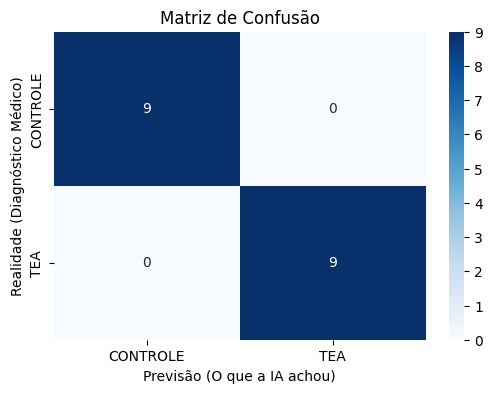

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n" + "="*60)
print("🧠 PROVA DE CONCEITO: TREINAMENTO DO RANDOM FOREST")
print("="*60)

# 1. CARREGAR OS DADOS
caminho_dados = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
df = pd.read_csv(caminho_dados)

# 2. PREPARAÇÃO DOS DADOS (Features e Target)
# Variáveis que a IA vai usar para aprender (X)
X = df[['Pupila_Media_mm', 'OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms']]

# A resposta que a IA tem de adivinhar (y)
y = df['Grupo']

# 3. DIVISÃO DE TREINO E TESTE
# 70% para estudar (treino), 30% para a prova final (teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Volume de Treino: {len(X_train)} faces")
print(f"Volume de Teste: {len(X_test)} faces\n")

# 4. TREINAMENTO DO MODELO
# Criamos uma floresta com 100 árvores de decisão
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
modelo_rf.fit(X_train, y_train) # A IA estuda aqui

# 5. AVALIAÇÃO (A PROVA)
y_pred = modelo_rf.predict(X_test) # A IA faz a prova cega aqui

# 6. MÉTRICAS E RESULTADOS
acuracia = accuracy_score(y_test, y_pred)
print(f"🏆 Acurácia Geral do Modelo: {acuracia * 100:.2f}%\n")

print("📊 Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

# 7. O QUE A IA ACHOU MAIS IMPORTANTE? (Feature Importance)
importancias = modelo_rf.feature_importances_
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\n🔍 Importância das Variáveis (O que mais pesou na decisão):")
for idx, row in features_df.iterrows():
    print(f" - {row['Feature']}: {row['Importancia']*100:.1f}%")

# Bônus: Matriz de Confusão Visual
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo_rf.classes_, yticklabels=modelo_rf.classes_)
plt.title('Matriz de Confusão')
plt.ylabel('Realidade (Diagnóstico Médico)')
plt.xlabel('Previsão (O que a IA achou)')
plt.show()


INICIANDO GERAÇÃO DAS 3 VIEWS DE OURO DO EYE TRACKING
Gerando View 1: Assinatura de Atenção...
Gerando View 2: Variância Foco nos Olhos...


/tmp/ipykernel_4080/1201652958.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g1 = sns.barplot(x='AOI_Label', y='Tempo_ms', hue='Grupo', data=df_long_aoi, ci=None, ax=axes[0])


Gerando View 3: Carga Cognitiva vs. Emoção...


/tmp/ipykernel_4080/1201652958.py:61: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g3 = sns.pointplot(x='Emocao', y='Pupila_Media_mm', hue='Grupo', data=df,



🎯 3 VIEWS CONCLUÍDAS. EXIBINDO PLOTS.


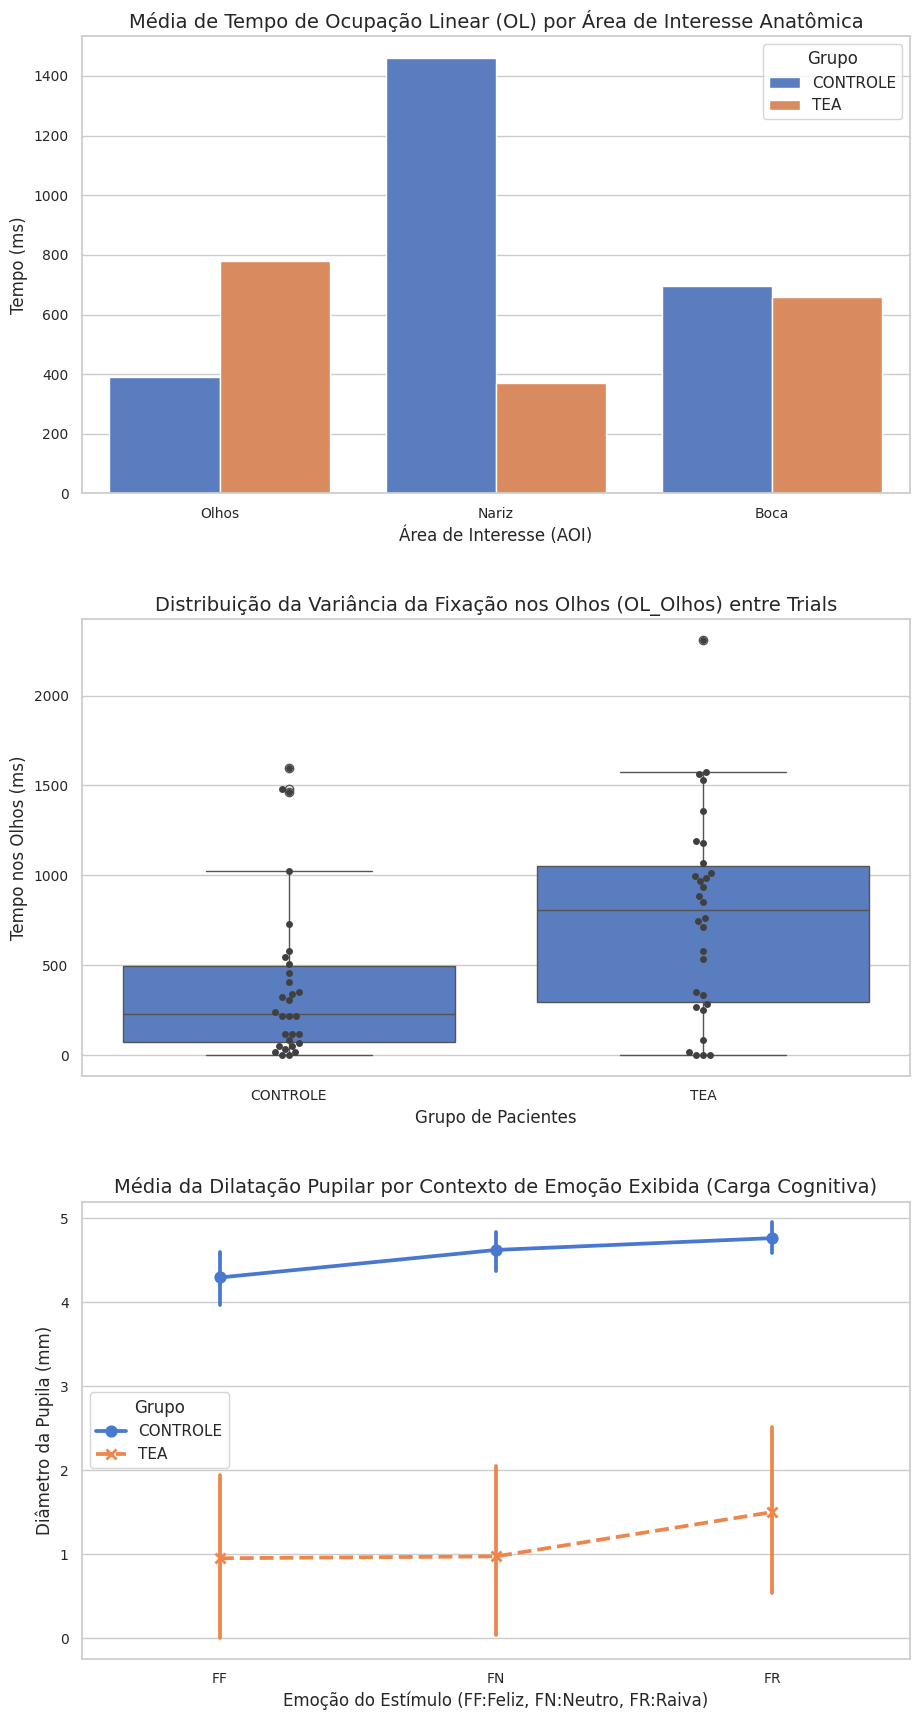

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurações de estilo para qualidade de publicação
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("\n" + "="*60)
print("INICIANDO GERAÇÃO DAS 3 VIEWS DE OURO DO EYE TRACKING")
print("="*60)

# 1. CARREGAR OS DADOS (Resultados da PoC)
caminho_dados = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
df = pd.read_csv(caminho_dados)

# Dicionário para legendas mais bonitas baseadas na tese
labels_aoi = {'OL_Olhos_ms': 'Olhos', 'OL_Nariz_ms': 'Nariz', 'OL_Boca_ms': 'Boca'}

# Preparamos o layout dos gráficos (3 linhas, 1 coluna)
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# ============================================================
# VIEW 1: ASSINATURA DA ALOCAÇÃO DE ATENÇÃO (Grouped Bar Chart)
# Foco: Onde eles olharam, em média.
# ============================================================
print("Gerando View 1: Assinatura de Atenção...")
# Transformamos os dados em formato longo para plotagem categórica
df_long_aoi = df.melt(id_vars=['Grupo'], value_vars=['OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms'],
                        var_name='AOI', value_name='Tempo_ms')
# Mapeamos as AOIs para os nomes corretos
df_long_aoi['AOI_Label'] = df_long_aoi['AOI'].map(labels_aoi)

g1 = sns.barplot(x='AOI_Label', y='Tempo_ms', hue='Grupo', data=df_long_aoi, ci=None, ax=axes[0])
g1.set_title('Média de Tempo de Ocupação Linear (OL) por Área de Interesse Anatômica', fontsize=14)
g1.set_ylabel('Tempo (ms)', fontsize=12)
g1.set_xlabel('Área de Interesse (AOI)', fontsize=12)
axes[0].tick_params(labelsize=10)


# ============================================================
# VIEW 2: DISTRIBUIÇÃO E VARIÂNCIA DO FOCO NOS OLHOS (Boxplot + Swarm)
# Foco: Quão consistente é o foco no olhar?
# ============================================================
print("Gerando View 2: Variância Foco nos Olhos...")
g2 = sns.boxplot(x='Grupo', y='OL_Olhos_ms', data=df, ax=axes[1])
# Adicionamos os pontos individuais (trials) para transparência dos dados
sns.swarmplot(x='Grupo', y='OL_Olhos_ms', data=df, color=".25", size=5, ax=axes[1])
g2.set_title('Distribuição da Variância da Fixação nos Olhos (OL_Olhos) entre Trials', fontsize=14)
g2.set_ylabel('Tempo nos Olhos (ms)', fontsize=12)
g2.set_xlabel('Grupo de Pacientes', fontsize=12)
axes[1].tick_params(labelsize=10)


# ============================================================
# VIEW 3: CARGA COGNITIVA POR CONTEXTO EMOCIONAL (Pointplot)
# Foco: Como a pupila reage a diferentes emoções.
# ============================================================
print("Gerando View 3: Carga Cognitiva vs. Emoção...")
g3 = sns.pointplot(x='Emocao', y='Pupila_Media_mm', hue='Grupo', data=df, 
                   join=True, markers=["o", "x"], linestyles=["-", "--"], ax=axes[2])
g3.set_title('Média da Dilatação Pupilar por Contexto de Emoção Exibida (Carga Cognitiva)', fontsize=14)
g3.set_ylabel('Diâmetro da Pupila (mm)', fontsize=12)
g3.set_xlabel('Emoção do Estímulo (FF:Feliz, FN:Neutro, FR:Raiva)', fontsize=12)
axes[2].tick_params(labelsize=10)

plt.tight_layout(pad=3.0)
print("\n" + "="*60)
print("🎯 3 VIEWS CONCLUÍDAS. EXIBINDO PLOTS.")
print("="*60)
plt.show()


🧠 PROVA DE CONCEITO: MACHINE LEARNING SEPARADO POR EMOÇÃO

--- Treinando Modelo para Face: Feliz (FF) ---
Volume de Treino: 14 faces | Volume de Teste: 6 faces
🏆 Acurácia: 83.33%
🔍 Top Variável para diferenciar TEA/Controle em faces Feliz: Pupila_Media_mm (61.2%)

--- Treinando Modelo para Face: Neutra (FN) ---
Volume de Treino: 14 faces | Volume de Teste: 6 faces
🏆 Acurácia: 100.00%
🔍 Top Variável para diferenciar TEA/Controle em faces Neutra: Pupila_Media_mm (54.3%)

--- Treinando Modelo para Face: Raiva (FR) ---
Volume de Treino: 14 faces | Volume de Teste: 6 faces
🏆 Acurácia: 100.00%
🔍 Top Variável para diferenciar TEA/Controle em faces Raiva: Pupila_Media_mm (48.7%)

GERANDO VISUALIZAÇÕES COMPARATIVAS POR EMOÇÃO...


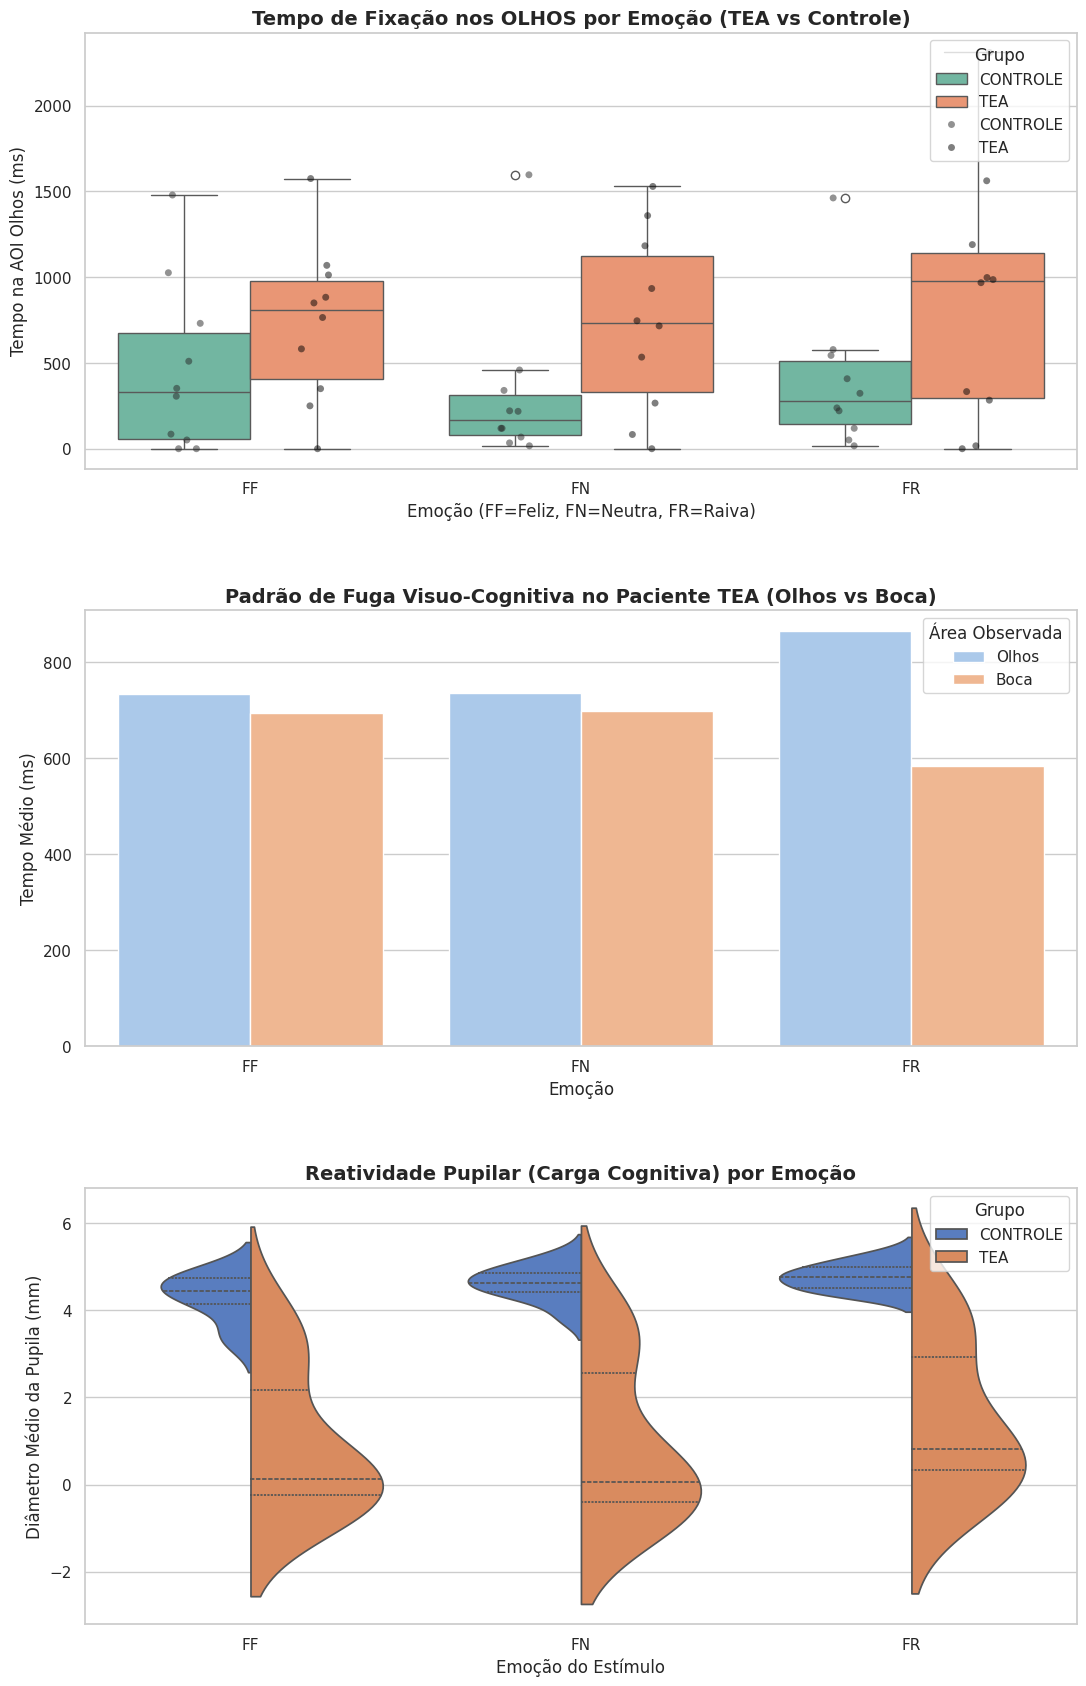

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings

# Silenciar avisos de amostra pequena
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("🧠 PROVA DE CONCEITO: MACHINE LEARNING SEPARADO POR EMOÇÃO")
print("="*80)

# 1. CARREGAR OS DADOS
caminho_dados = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
try:
    df = pd.read_csv(caminho_dados)
except FileNotFoundError:
    print("Ficheiro não encontrado. Certifique-se de que rodou o código de extração anterior.")
    raise

emocoes = ['FF', 'FN', 'FR']
nomes_emocoes = {'FF': 'Feliz', 'FN': 'Neutra', 'FR': 'Raiva'}

# 2. TREINAMENTO DE 3 MODELOS INDEPENDENTES
for emo in emocoes:
    print(f"\n--- Treinando Modelo para Face: {nomes_emocoes[emo]} ({emo}) ---")
    
    # Filtramos o dataset apenas para a emoção atual
    df_emo = df[df['Emocao'] == emo]
    
    if len(df_emo) < 10:
        print(f"Dados insuficientes para {emo}.")
        continue
        
    X = df_emo[['Pupila_Media_mm', 'OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms']]
    y = df_emo['Grupo']
    
    # Divisão de Treino e Teste (Atenção: Amostra minúscula de 20 linhas)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
    
    modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3)
    modelo_rf.fit(X_train, y_train)
    
    y_pred = modelo_rf.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)
    
    print(f"Volume de Treino: {len(X_train)} faces | Volume de Teste: {len(X_test)} faces")
    print(f"🏆 Acurácia: {acuracia * 100:.2f}%")
    
    # Importância das Variáveis
    importancias = modelo_rf.feature_importances_
    features_df = pd.DataFrame({'Feature': X.columns, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)
    
    print(f"🔍 Top Variável para diferenciar TEA/Controle em faces {nomes_emocoes[emo]}: {features_df.iloc[0]['Feature']} ({features_df.iloc[0]['Importancia']*100:.1f}%)")

# ============================================================
# GERAÇÃO DAS 3 VIEWS FOCADAS EM EMOÇÃO
# ============================================================
print("\n" + "="*80)
print("GERANDO VISUALIZAÇÕES COMPARATIVAS POR EMOÇÃO...")
print("="*80)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# VIEW 1: FOCO NOS OLHOS SEPARADO POR EMOÇÃO (Boxplot)
# O objetivo aqui é ver se o TEA desvia o olhar dos olhos mais na face de Raiva ou na Feliz
sns.boxplot(x='Emocao', y='OL_Olhos_ms', hue='Grupo', data=df, ax=axes[0], palette="Set2")
sns.stripplot(x='Emocao', y='OL_Olhos_ms', hue='Grupo', data=df, dodge=True, color='black', alpha=0.5, ax=axes[0])
axes[0].set_title('Tempo de Fixação nos OLHOS por Emoção (TEA vs Controle)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tempo na AOI Olhos (ms)', fontsize=12)
axes[0].set_xlabel('Emoção (FF=Feliz, FN=Neutra, FR=Raiva)', fontsize=12)
axes[0].legend(title='Grupo', loc='upper right')

# VIEW 2: MAPA DE ATENÇÃO (OLHOS VS BOCA) POR EMOÇÃO
# O objetivo é verificar a tese de que o TEA procura a boca como fuga cognitiva
df_melt = df.melt(id_vars=['Grupo', 'Emocao'], value_vars=['OL_Olhos_ms', 'OL_Boca_ms'], var_name='AOI', value_name='Tempo_ms')
df_melt['AOI'] = df_melt['AOI'].replace({'OL_Olhos_ms': 'Olhos', 'OL_Boca_ms': 'Boca'})

sns.barplot(x='Emocao', y='Tempo_ms', hue='AOI', data=df_melt[df_melt['Grupo']=='TEA'], ax=axes[1], ci=None, palette="pastel")
axes[1].set_title('Padrão de Fuga Visuo-Cognitiva no Paciente TEA (Olhos vs Boca)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tempo Médio (ms)', fontsize=12)
axes[1].set_xlabel('Emoção', fontsize=12)
axes[1].legend(title='Área Observada', loc='upper right')

# VIEW 3: CARGA COGNITIVA E DILATAÇÃO PUPILAR
# Medimos a ativação do sistema nervoso simpático face a diferentes estímulos
sns.violinplot(x='Emocao', y='Pupila_Media_mm', hue='Grupo', data=df, split=True, inner="quart", ax=axes[2], palette="muted")
axes[2].set_title('Reatividade Pupilar (Carga Cognitiva) por Emoção', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Diâmetro Médio da Pupila (mm)', fontsize=12)
axes[2].set_xlabel('Emoção do Estímulo', fontsize=12)
axes[2].legend(title='Grupo', loc='upper right')

plt.tight_layout(pad=4.0)
plt.show()